In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy


from scipy.spatial.distance import pdist, squareform
from collections import defaultdict

sc.settings.verbosity = 2

# Load in processed anndata

In [2]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.37 GB, difference +2.37 GB
CPU times: user 267 ms, sys: 1.66 s, total: 1.93 s
Wall time: 4.77 s


/home/jrcwycy/miniconda3/envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'means', 'variance

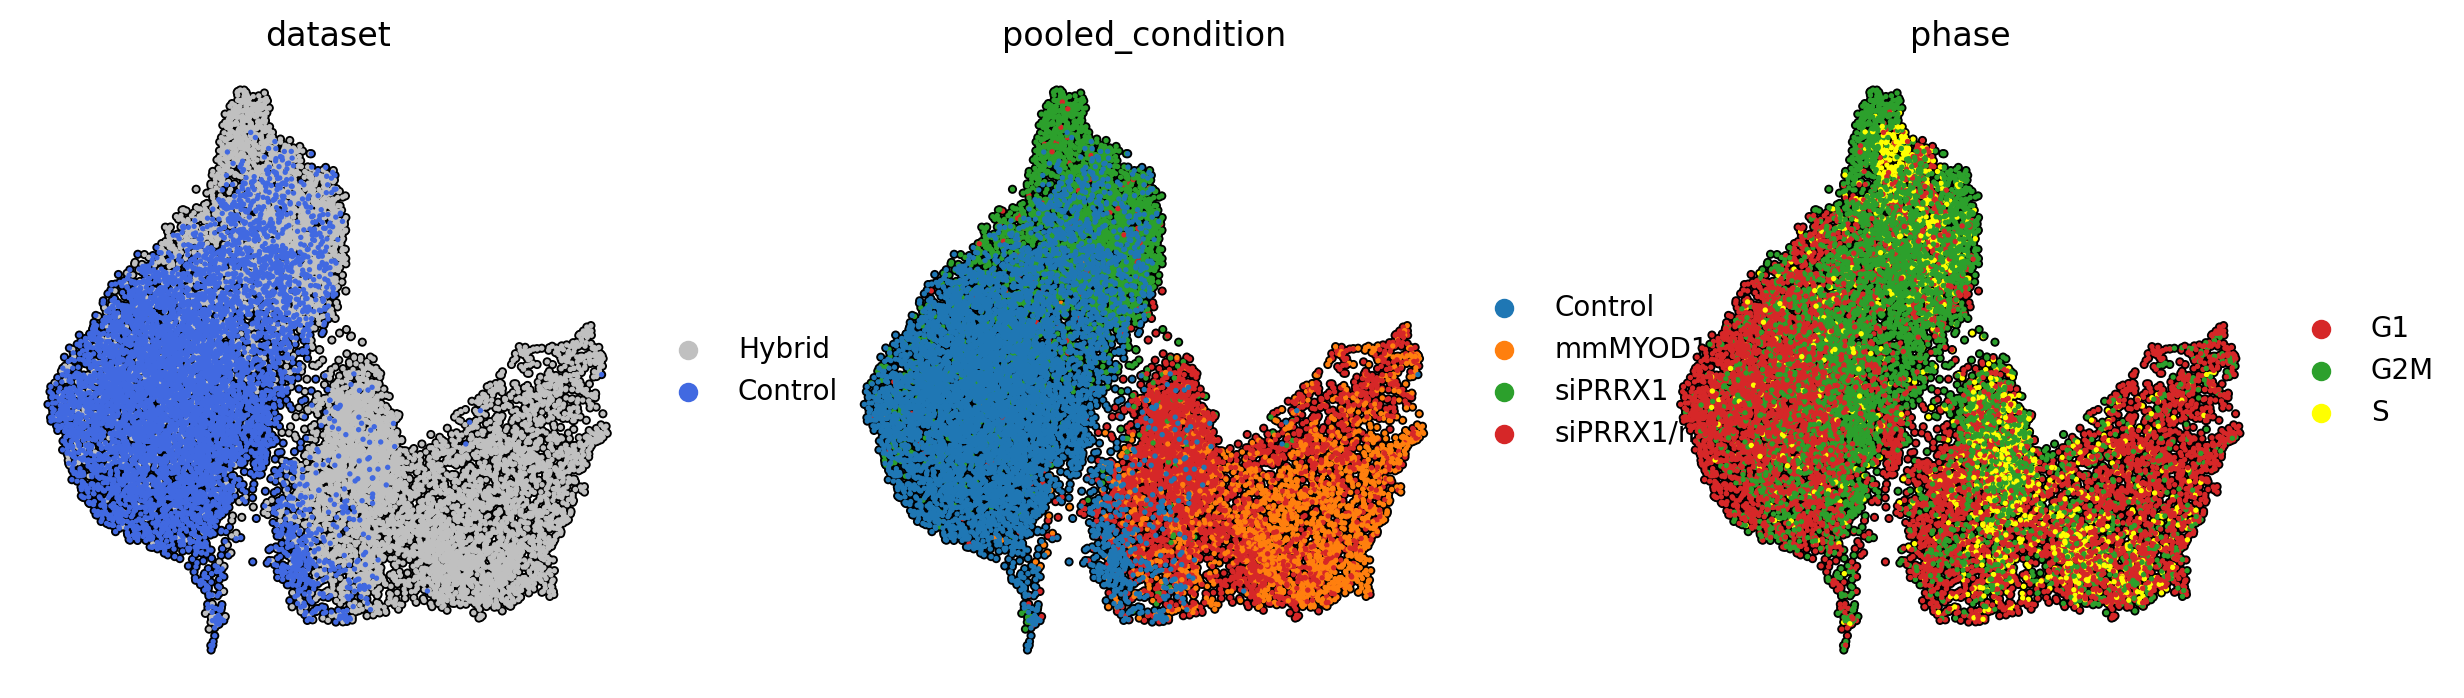

In [4]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['dataset', 'pooled_condition', 'phase'],
    size=15,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

# Get cell cycle genes

In [3]:
# GO cell cycle genes
fpath = "../../resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
go_cc_genes = cdf['gene_name'].unique()
print(f"N unique GO cell cycle genes: {cdf['gene_name'].nunique()}")

# Regev cell cycle genes
fpath = "../../resources/regev_lab_cell_cycle_genes.txt"
regev_genes = [x.strip() for x in open(fpath)]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]


cc_genes = list(set(go_cc_genes) | set(regev_genes))
print(len(cc_genes))

N unique GO cell cycle genes: 142
235


In [4]:
phase_map = {
    'G1': 'G1 Phase',
    'G1/S_transition': 'G1/S Transition Checkpoint Signaling',
    'S': 'S Phase',
    'G2': 'G2 Phase',
    'G2/M_transition': 'G2/M Transition Checkpoint Signaling',
    'M': 'M Phase',
}

cc_dict = {
    short_name: cdf.loc[cdf[col_name] == True, 'gene_name'].tolist()
    for short_name, col_name in phase_map.items()
}

for gene in s_genes:
    if gene not in cc_dict["S"]:
        cc_dict["S"].append(gene)

cc_dict["G2M"] = list(g2m_genes)

# Remove unique G2 and M keys, add to G2M key
for gene in cc_dict.get("G2", []) + cc_dict.get("M", []):
    if gene not in cc_dict["G2M"]:
        cc_dict["G2M"].append(gene)
        
        
cc_dict.pop("G2", None)
cc_dict.pop("M", None)

['CNOT6', 'CSDE1', 'DRD2', 'DRD3', 'DRD4', 'HBS1L', 'PELO']

In [6]:
cc_dict.keys()

dict_keys(['G1', 'G1/S_transition', 'S', 'G2/M_transition', 'G2M'])

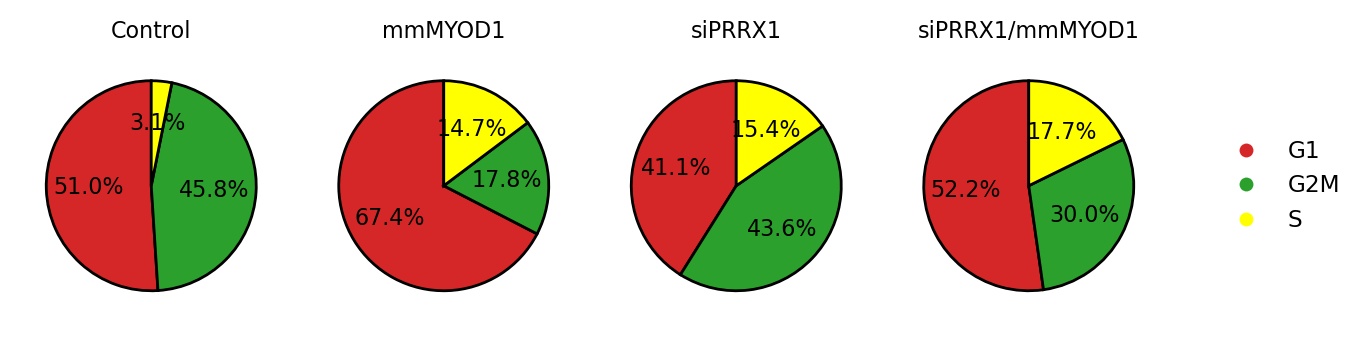

In [16]:
counts = adata.obs.groupby(['pooled_condition', 'phase'], observed=True).size().reset_index(name='count')
pivot_counts = counts.pivot(index='pooled_condition', columns='phase', values='count').fillna(0)

color_map = {
    "G1": "tab:red",
    "G2M": "tab:green",
    "S": "yellow",
}

clusters = pivot_counts.index.tolist()

plt.rcParams['figure.figsize'] = 6, 2
plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(1, 4)
axes = axes.flatten()

# Donut plots
for i, cluster in enumerate(clusters):
    ax = axes[i]
    data = pivot_counts.loc[cluster]
    colors = [color_map[cond] for cond in data.index]

    wedges, label, pcts = ax.pie(
        data,
        labels=None,
        startangle=90,
        colors=colors,
        wedgeprops=dict(linewidth=1, edgecolor='k'),#, width=0.45),
        autopct='%1.1f%%',
        # pctdistance=0.75,
    )
    
    for pct in pcts:
        pct.set_color("black")
        pct.set_fontsize(8)
        
    ax.set(aspect='equal')
    ax.set_title(f"{cluster}", fontsize=8)
    
# Hide any extra subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')


fig.legend(
    handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[cond], markersize=6) 
             for cond in color_map],
    labels=color_map.keys(),
    loc='center left',
    bbox_to_anchor=(1.01, 0.5),
    fontsize='small',
    frameon=False
)

plt.tight_layout()
plt.show()

# DGE

In [8]:
def get_significant_DEGs(df, alpha=0.05, logfc_thresh=0.5, pct_nz_thresh=0.0):
    
    """ Filters DGE results for significant differentially expressed genes. 
    
    Params
    ------
        df (pd.DataFrame): Dataframe containing DGE results.
        alpha (float): Adjusted p-value threshold for statistical significance. Genes below this threshold are considered significant.
        logfc_thresh (float): Minimum absolute logfoldchange required for a gene to be considered significantly DE. 
        pct_nz_thresh (float): Minimum proportion of cells in the group of interest expressing the gene. Genes expressed in fewer cells than this threshold will be excluded.
    
    """
    
    tmp = df.copy()
    
    print(f"Filtering for significant DEGs (adjusted p-value < {alpha}, logfoldchange > {logfc_thresh})...")

    tmp['abs_lfc'] = tmp['logfoldchanges'].apply('abs')
    tmp = tmp[(tmp['abs_lfc'] > logfc_thresh) & (tmp['pvals_adj'] < alpha)]
    
    # tmp = tmp[(tmp['pct_nz_group'] > pct_nz_thresh) | (tmp['pct_nz_reference'] > pct_nz_thresh)]
    
    if pct_nz_thresh != 0.0:
        tmp = tmp[(tmp['pct_nz_group'] > pct_nz_thresh) | (tmp['pct_nz_reference'] > pct_nz_thresh)]
        print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
    
    print(f"N unique significant DEGs: {tmp['names'].nunique()}\n")
    
    return tmp

## By condition

mmMYOD1, siPRRX1, siPRRX1/mmMYOD1, Controls

In [12]:
# all groups vs each other
sc.tl.rank_genes_groups(
    adata, 
    groupby="pooled_condition",
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='each_vs_rest',
)

# hyb groups vs controls
sc.tl.rank_genes_groups(
    adata, 
    groupby="pooled_condition",
    reference='Control',
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='condition_vs_control',
)

ranking genes
    finished (0:00:36)
ranking genes
    finished (0:00:58)


## By condition with controls grouped by phase

Control (G1/S), Control (G2/M), HYB conditions

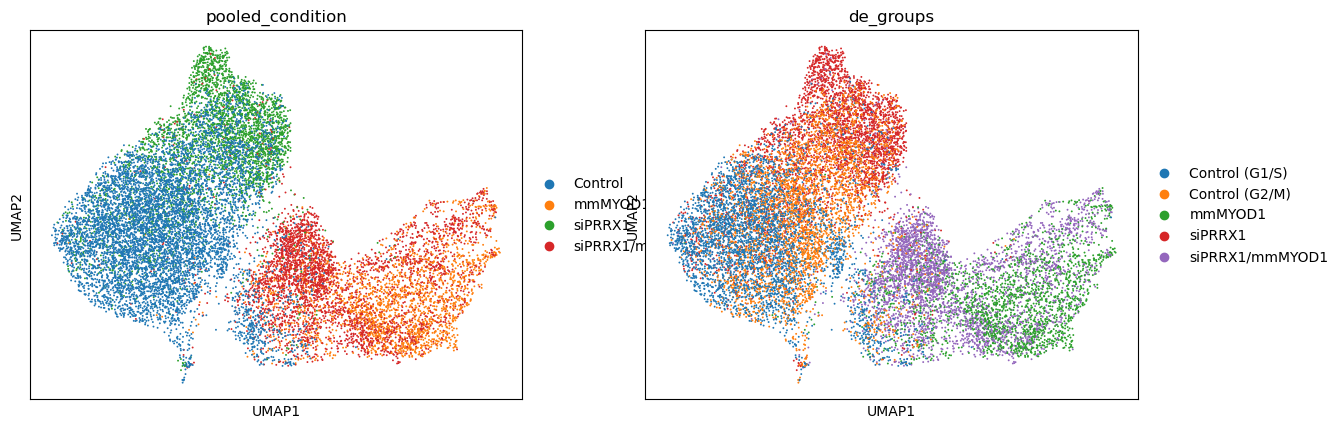

In [13]:
adata.obs["de_groups"] = adata.obs["pooled_condition"].astype(str)

# For control cells, split based on phase
adata.obs.loc[
    (adata.obs["pooled_condition"] == "Control") & 
    (adata.obs["phase"].isin(["G1", "S"])), 
    "de_groups"
] = "Control (G1/S)"

adata.obs.loc[
    (adata.obs["pooled_condition"] == "Control") & 
    (adata.obs["phase"] == "G2M"), 
    "de_groups"
] = "Control (G2/M)"

# Make sure it's categorical
adata.obs["de_groups"] = adata.obs["de_groups"].astype("category")

plt.rcdefaults()
sc.pl.umap(
    adata,
    color=['pooled_condition', 'de_groups'],
    ncols=2,
)

In [14]:
# hyb groups vs controls
sc.tl.rank_genes_groups(
    adata, 
    groupby="de_groups",
    reference='Control (G1/S)',
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='condition_vs_G1_S',
)

# hyb groups vs controls
sc.tl.rank_genes_groups(
    adata, 
    groupby="de_groups",
    reference='Control (G2/M)',
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='condition_vs_G2M',
)

ranking genes
    finished (0:00:50)
ranking genes
    finished (0:00:47)


In [20]:
# deg = sc.get.rank_genes_groups_df(
#     adata, 
#     group=None,
#     key='condition_vs_control',
# )

hyb_groups = ['mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=hyb_groups,
    # key='condition_vs_G2M',
    key='condition_vs_G1_S',
)

sig = get_significant_DEGs(deg)

print(sig.shape)
sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
N unique significant DEGs: 10215

(22210, 8)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc
0,mmMYOD1,MYOD1,63.691422,32.184513,0.0,0.0,1.000000,32.184513
1,mmMYOD1,MT-ND4,63.585537,2.853245,0.0,0.0,0.999526,2.853245
2,mmMYOD1,LINC-PINT,54.247398,2.778310,0.0,0.0,0.970128,2.778310
3,mmMYOD1,KCNQ5,53.647049,3.624084,0.0,0.0,0.952584,3.624084
4,mmMYOD1,NAV3,53.642731,3.530347,0.0,0.0,0.924609,3.530347


# Cell cycle DEGs

In [21]:
sig = sig[sig['names'].isin(cc_genes)]
print(f"Total genes: {sig['names'].nunique()}\n")
print(f"{sig.groupby('group')['names'].nunique()}\n")

for phase, genes in cc_dict.items():
    sig[phase] = sig['names'].isin(genes)

sig.head()

Total genes: 167

group
mmMYOD1            142
siPRRX1            146
siPRRX1/mmMYOD1    143
Name: names, dtype: int64



,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,G1,G1/S_transition,S,G2/M_transition,G2M
8,mmMYOD1,GMNN,46.736504,2.956674,0.000000e+00,0.000000e+00,0.880038,2.956674,False,False,True,False,False
87,mmMYOD1,NES,31.752443,2.411844,2.938036e-221,2.452477e-219,0.659080,2.411844,False,False,False,True,False
232,mmMYOD1,CCND1,25.044903,0.996572,1.984005e-138,8.777996e-137,0.863917,0.996572,False,True,False,False,False
242,mmMYOD1,PLK2,24.652706,2.757543,3.442300e-134,1.466022e-132,0.534851,2.757543,False,True,False,False,False
255,mmMYOD1,NASP,24.140293,1.082748,9.442294e-129,3.857323e-127,0.824561,1.082748,False,False,True,False,False


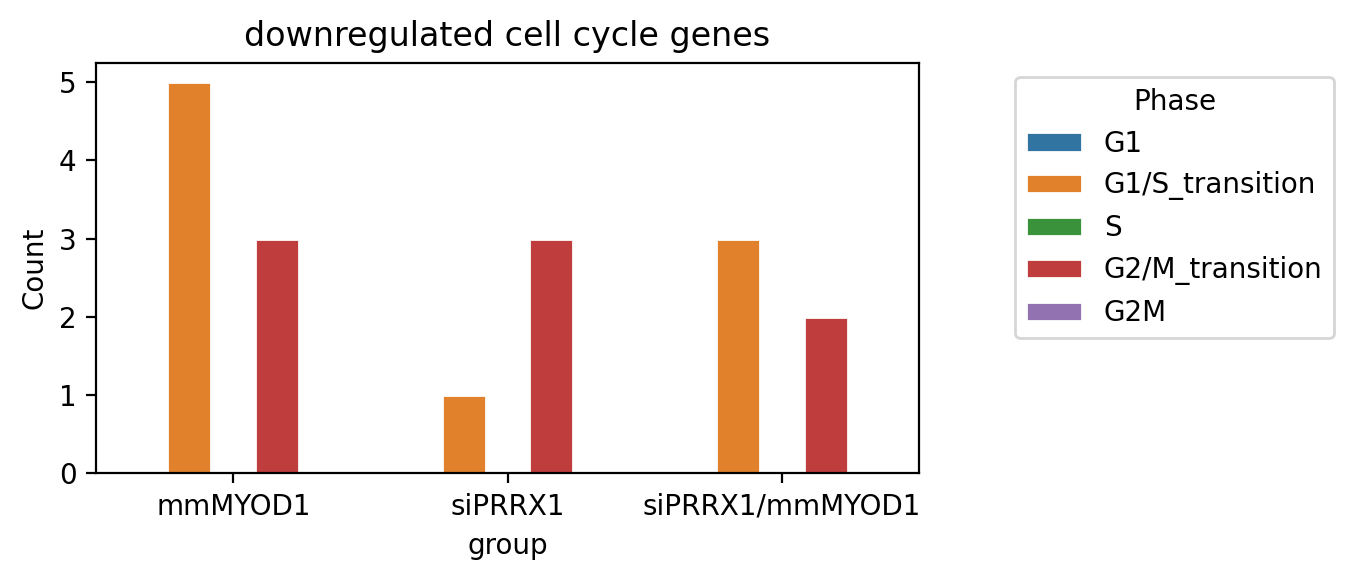

In [23]:
direction = 'downregulated'

if direction == 'upregulated':
    tmp = sig[sig['logfoldchanges'] > 0]
else:
    tmp = sig[sig['logfoldchanges'] < 0]
    
    

counts = tmp.groupby('group')[list(cc_dict.keys())].sum().reset_index()

counts_tidy = counts.melt(id_vars='group', 
                                var_name='Phase', 
                                value_name='Count')


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 7, 3

sns.barplot(
    data=counts_tidy,
    x='group',
    y='Count',
    hue='Phase',
    ec='white',
)

sns.move_legend(plt.gca(), loc='upper left', bbox_to_anchor=(1.1, 1))

plt.title(f"{direction} cell cycle genes")

plt.tight_layout()
plt.show()    

In [119]:
sig.sort_values(by='names')['names'].unique()

array(['ACVR1B', 'ANLN', 'ANP32E', 'APP', 'AURKA', 'AURKB', 'BIRC5',
       'BLM', 'BRIP1', 'BRSK1', 'BTN2A2', 'BUB1', 'CACUL1', 'CALM1',
       'CALM2', 'CALM3', 'CASP8AP2', 'CBX5', 'CCDC57', 'CCNA2', 'CCNB1',
       'CCNB2', 'CCND1', 'CCND3', 'CCNE2', 'CCNY', 'CDC20', 'CDC25B',
       'CDC25C', 'CDC6', 'CDC7', 'CDCA2', 'CDCA3', 'CDCA7', 'CDCA8',
       'CDK1', 'CDK6', 'CDKN1A', 'CDKN1B', 'CDKN3', 'CENPA', 'CENPE',
       'CENPF', 'CHAF1B', 'CHEK2', 'CKAP2', 'CKAP2L', 'CKAP5', 'CKS1B',
       'CNOT6', 'CSDE1', 'CUL1', 'CUL3', 'CUL4B', 'DLGAP5', 'DNM2', 'DTL',
       'E2F3', 'E2F8', 'ECT2', 'EIF4E', 'EIF4EBP1', 'ENSA', 'EXO1',
       'FBXL7', 'FOXM1', 'GAS2L3', 'GINS2', 'GMNN', 'GTSE1', 'HBS1L',
       'HINFP', 'HJURP', 'HMGB2', 'HMMR', 'HSPA8', 'ID4', 'IQGAP3',
       'ITGB1', 'KIF11', 'KIF20B', 'KIF23', 'KIF2C', 'LATS1', 'LATS2',
       'LBR', 'LCMT1', 'MASTL', 'MCM2', 'MCM4', 'MCM5', 'MKI67', 'MNAT1',
       'MSH2', 'MYC', 'NASP', 'NCAPD2', 'NDC80', 'NEK2', 'NES', 'NUF2',
       'NU

In [24]:
group = 'siPRRX1'
direction = 'upregulated'

tmp = sig[sig['group'] == group]

if direction == 'upregulated':
    tmp = tmp[tmp['logfoldchanges'] > 0]
else:
    tmp = tmp[tmp['logfoldchanges'] < 0]

print(f"DE {direction} genes for {group} cells: {tmp['names'].nunique()}") 
tmp.sort_values(by='names')['names'].unique()
    
# tmp.head()

DE upregulated genes for siPRRX1 cells: 142


array(['ANLN', 'ANP32E', 'ATAD2', 'AURKA', 'AURKB', 'BIRC5', 'BLM',
       'BRIP1', 'BTN2A2', 'BUB1', 'CASP8AP2', 'CBX5', 'CCDC57', 'CCNA2',
       'CCNB1', 'CCNB2', 'CCND1', 'CCNE2', 'CCNY', 'CDC20', 'CDC25A',
       'CDC25C', 'CDC45', 'CDC6', 'CDC7', 'CDCA2', 'CDCA3', 'CDCA7',
       'CDCA8', 'CDK1', 'CDK14', 'CDK2', 'CDKN1A', 'CDKN1B', 'CDKN3',
       'CENPA', 'CENPE', 'CENPF', 'CHAF1B', 'CHEK1', 'CHEK2', 'CKAP2',
       'CKAP2L', 'CKAP5', 'CKS1B', 'CKS2', 'CLSPN', 'CNOT6', 'CTCF',
       'CUL1', 'CUL3', 'DBF4', 'DLGAP5', 'DNM2', 'DSCC1', 'DTL', 'E2F8',
       'ECT2', 'EIF4E', 'ENSA', 'EXO1', 'EZH2', 'FBXL7', 'FEN1', 'FOXM1',
       'G2E3', 'GAS2L3', 'GINS2', 'GMNN', 'GSPT1', 'GTSE1', 'HBS1L',
       'HELLS', 'HINFP', 'HJURP', 'HMGB2', 'HMMR', 'HSPA8', 'IQGAP3',
       'KHDRBS1', 'KIF11', 'KIF20B', 'KIF23', 'KIF2C', 'LATS1', 'LBR',
       'LCMT1', 'MASTL', 'MCM2', 'MCM4', 'MCM5', 'MCM6', 'MELK', 'MKI67',
       'MSH2', 'NASP', 'NCAPD2', 'NDC80', 'NEK2', 'NES', 'NUF2', 'NUSAP1',
    

In [81]:
cc_cols = list(cc_dict.keys())

tmp = tmp.sort_values(by='names')

for _, row in tmp.iterrows():
    gene = row['names']
    true_phases = [col for col in cc_cols if row[col]]
    print(f"{gene} - {', '.join(true_phases)}")

BRIP1 - S
BTN2A2 - G1/S_transition
CACUL1 - G1/S_transition
CCND3 - G1/S_transition
CCNY - G2/M_transition
CDK6 - G1/S_transition
CHEK2 - G2/M_transition
DNM2 - G2/M_transition
E2F3 - G1/S_transition
FBXL7 - G2/M_transition
GMNN - S
LATS1 - G1/S_transition, G2/M_transition
LATS2 - G1/S_transition
MNAT1 - G1/S_transition
MYC - G1/S_transition
NES - G2/M_transition
PELO - G1, G1/S_transition, S, G2/M_transition, G2M
PHF8 - G1/S_transition
PIAS1 - G1/S_transition
PLK2 - G1/S_transition
PLK3 - G1/S_transition, G2/M_transition
PPM1D - G2/M_transition
SPDYA - G1/S_transition
TERF2 - S
TERF2IP - S


## Overlap by condition

In [122]:
direction = 'Upregulated'

if direction == 'Upregulated':
    tmp = sig[sig['logfoldchanges'] > 0]
else:
    tmp = sig[sig['logfoldchanges'] < 0]

tmp = tmp.sort_values(by=['group', 'names'])

print(f"{direction} cell cycle genes\n")

myod_genes = set(tmp[tmp['group'] == 'mmMYOD1']['names'].unique())
prrx_genes = set(tmp[tmp['group'] == 'siPRRX1']['names'].unique())
hyb_genes = set(tmp[tmp['group'] == 'siPRRX1/mmMYOD1']['names'].unique())

print(f"Unique to mmMYOD1: {sorted(myod_genes - prrx_genes - hyb_genes)}\n")
print(f"Unique to siPRRX1: {sorted(prrx_genes - myod_genes - hyb_genes)}\n")
print(f"Unique to siPRRX1/mmMYOD1: {sorted(hyb_genes - myod_genes - prrx_genes)}\n")

print(f"Shared between mmMYOD1 + siPRRX1: {sorted((prrx_genes.intersection(myod_genes)) - hyb_genes)}\n")
print(f"Shared between mmMYOD1 + siPRRX1/mmMYOD1: {sorted((hyb_genes.intersection(myod_genes)) - prrx_genes)}\n")
print(f"Shared between siPRRX1 + siPRRX1/mmMYOD1: {sorted((hyb_genes.intersection(prrx_genes)) - myod_genes)}\n")
print(f"Shared by all: {sorted(hyb_genes.intersection(prrx_genes).intersection(myod_genes))}\n")

Upregulated cell cycle genes

Unique to mmMYOD1: ['ACVR1B', 'CACUL1', 'CDK6', 'E2F3', 'LATS2', 'LCMT1', 'MNAT1', 'TAF2', 'TERF2IP']

Unique to siPRRX1: ['AURKA', 'BIRC5', 'BUB1', 'CCNB1', 'CDC20', 'CDC7', 'CDKN1B', 'CDKN3', 'CENPF', 'CKAP5', 'CNOT6', 'DLGAP5', 'GINS2', 'HBS1L', 'HSPA8', 'LBR', 'MCM2', 'MCM4', 'MCM5', 'MKI67', 'MSH2', 'NCAPD2', 'PCNA', 'PLK1', 'POLE', 'RRM2', 'SMC4', 'TPX2', 'UBR7', 'UHRF1', 'WDR76']

Unique to siPRRX1/mmMYOD1: ['RANGAP1']

Shared between mmMYOD1 + siPRRX1: ['BRSK1', 'CCDC57', 'CUL1', 'GAS2L3', 'HINFP', 'RCC1', 'RPS6KB1']

Shared between mmMYOD1 + siPRRX1/mmMYOD1: ['CCND3', 'EIF4E', 'MASTL', 'MYC', 'PLK3', 'TIPIN']

Shared between siPRRX1 + siPRRX1/mmMYOD1: ['BLM', 'CDCA7', 'CHAF1B', 'DTL', 'EXO1']

Shared by all: ['BRIP1', 'BTN2A2', 'CASP8AP2', 'CCND1', 'CCNE2', 'CCNY', 'CDC6', 'CDKN1A', 'CHEK2', 'CUL3', 'DNM2', 'ENSA', 'FBXL7', 'GMNN', 'LATS1', 'NASP', 'NES', 'PELO', 'PHF8', 'PIAS1', 'PLCB1', 'PLK2', 'PPM1D', 'RFC2', 'RTEL1', 'SKP2', 'SPDYA', 'TERF2',

# Gene subsets

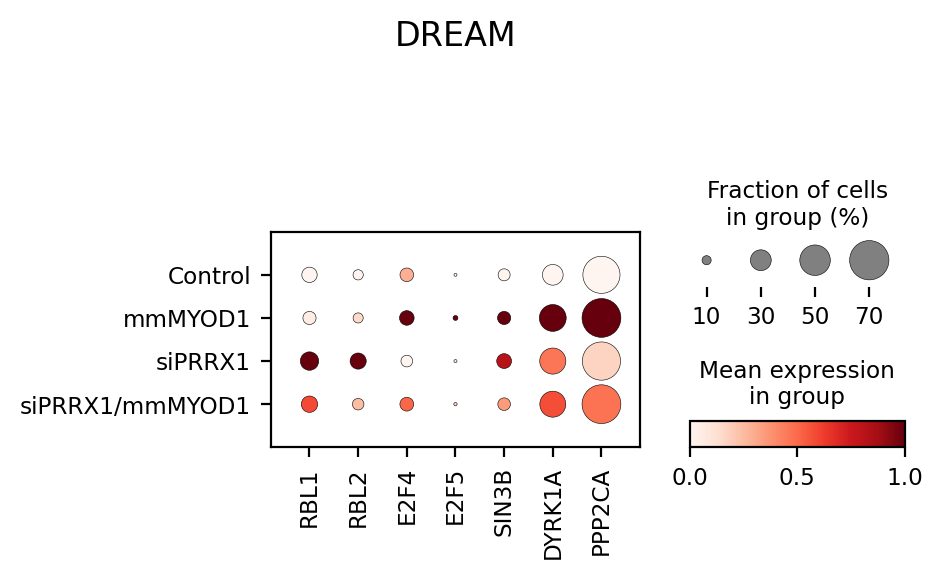

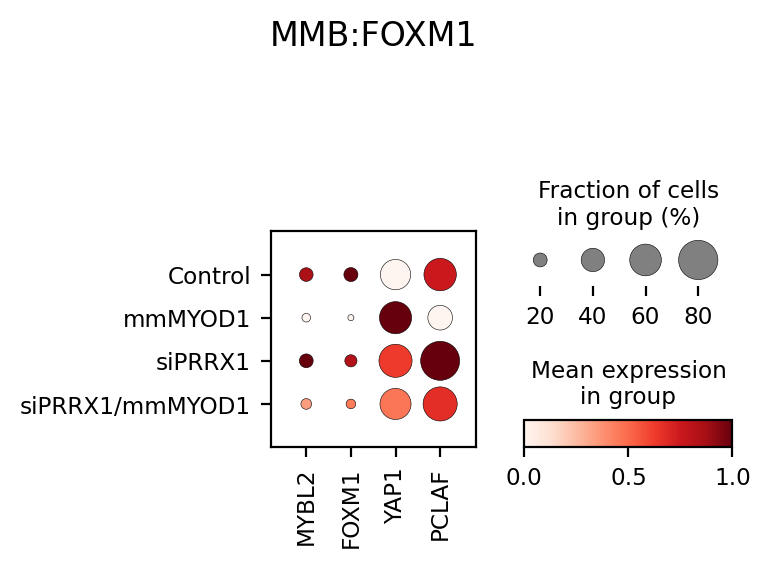

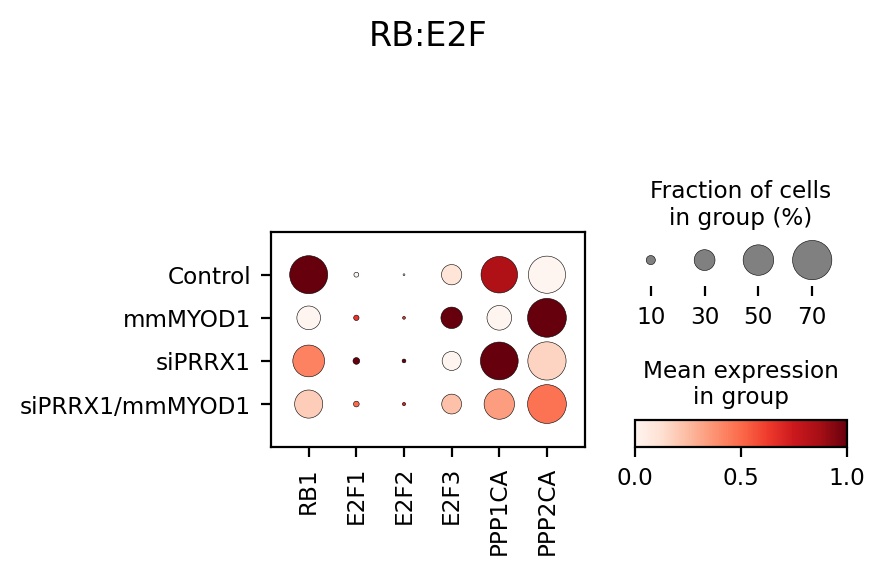

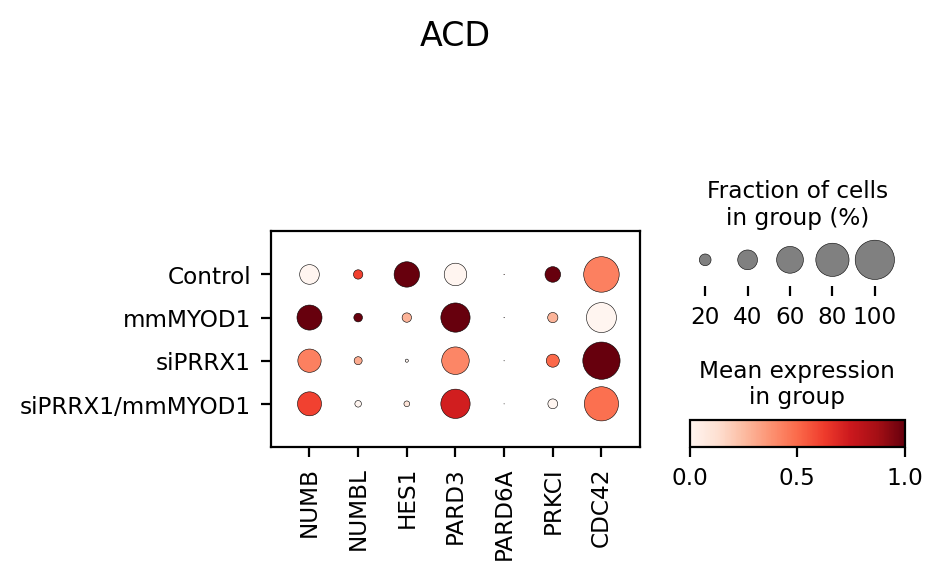

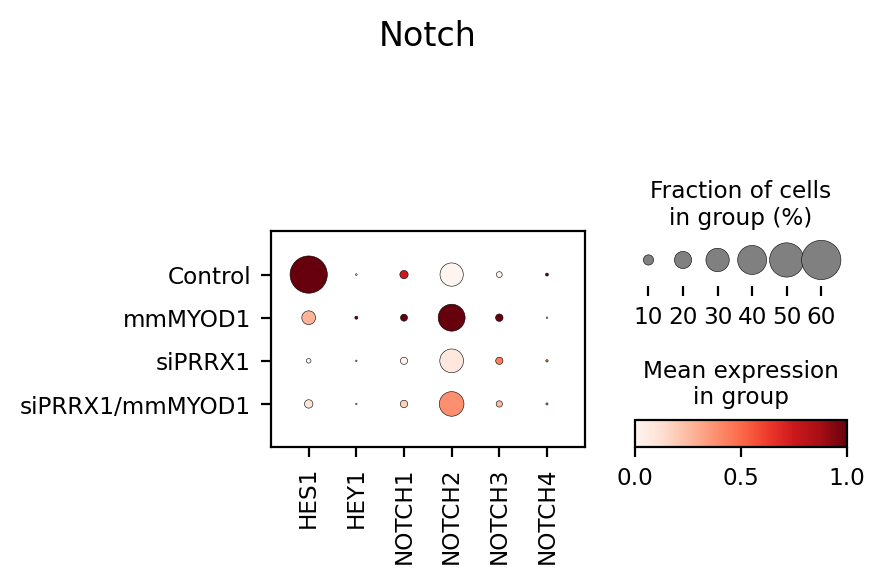

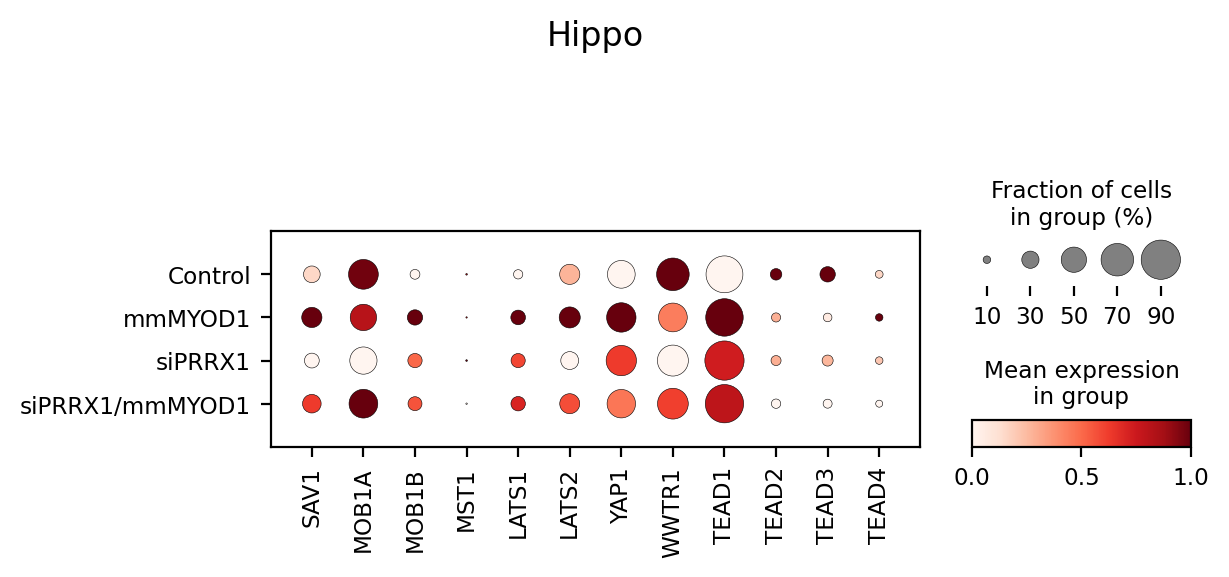

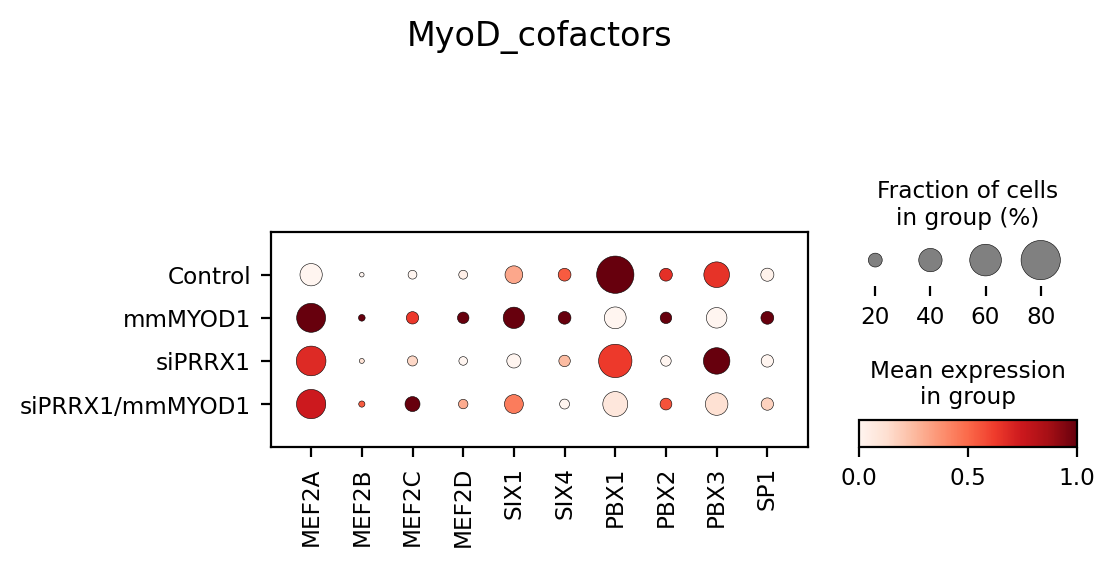

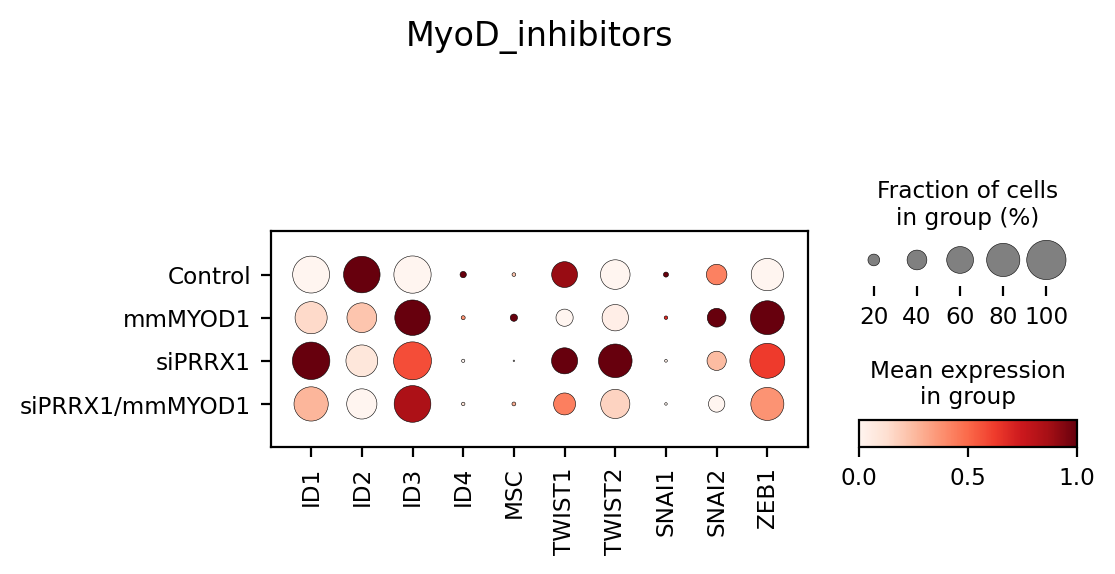

In [127]:
genes_of_interest = {
    "DREAM": ['RBL1', 'RBL2', 'E2F4', 'E2F5', 'SIN3B', 'DYRK1A', 'PPP2CA'],
    "MMB:FOXM1": ['MYBL2', 'FOXM1', 'YAP1', 'PCLAF'],
    "RB:E2F": ['RB1', 'E2F1', 'E2F2', 'E2F3', 'PPP1CA', 'PPP2CA'],
    "ACD": ['NUMB', 'NUMBL', 'HES1', 'PARD3', 'PARD6A', 'PRKCI', 'CDC42'],
    "Notch": ['HES1', 'HEY1', 'NOTCH1', 'NOTCH2', 'NOTCH3', 'NOTCH4'],
    "Hippo": ['SAV1', 'MOB1A', 'MOB1B', 'MST1', 'MST2', 'LATS1', 'LATS2', 'YAP1', 'WWTR1', 'TEAD1', 'TEAD2', 'TEAD3', 'TEAD4'],
    "MyoD_cofactors": ['MEF2A', 'MEF2B', 'MEF2C', 'MEF2D', 'SIX1', 'SIX4', 'PBX1', 'PBX2', 'PBX3', 'SP1'],
    "MyoD_inhibitors": ['ID1', 'ID2', 'ID3', 'ID4', 'MSC', 'MYOR', 'TWIST1', 'TWIST2', 'MIST1', 'BHLHA15', 'SNAI1', 'SNAI2', 'ZEB1'],
}


for pathway, genes in genes_of_interest.items():
    
    genes_to_plot = [gene for gene in genes if gene in adata.var_names]
    
    sc.pl.dotplot(
        adata,
        groupby='pooled_condition',
        var_names=genes_to_plot,
        layer='log_norm',
        title=pathway,
        standard_scale='var',
    )
    
    # break

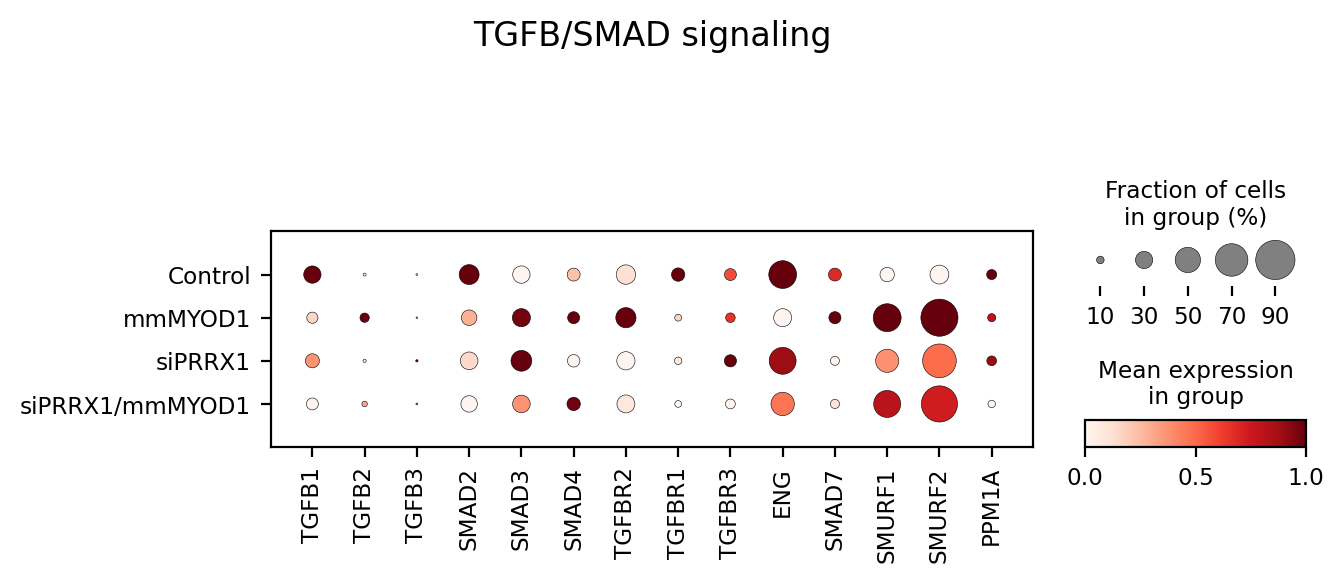

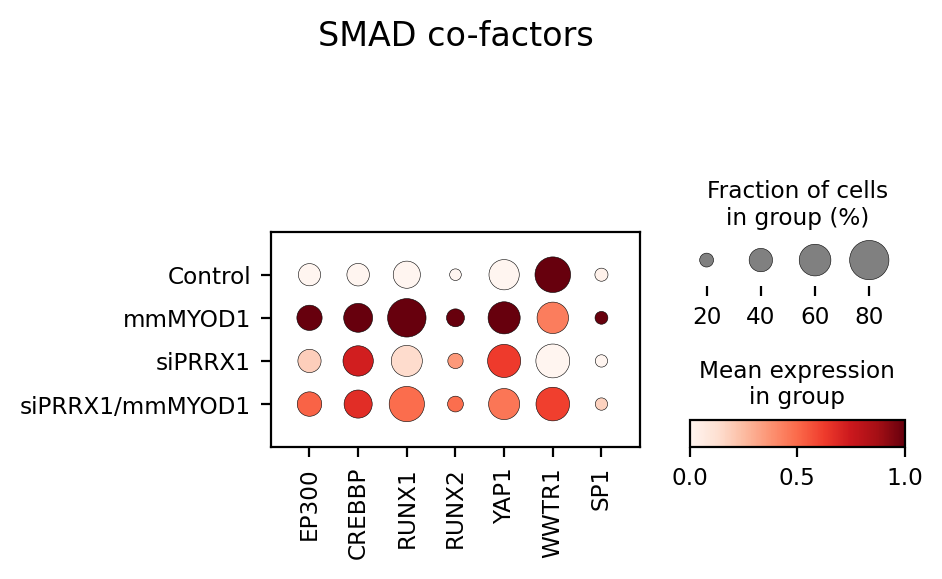

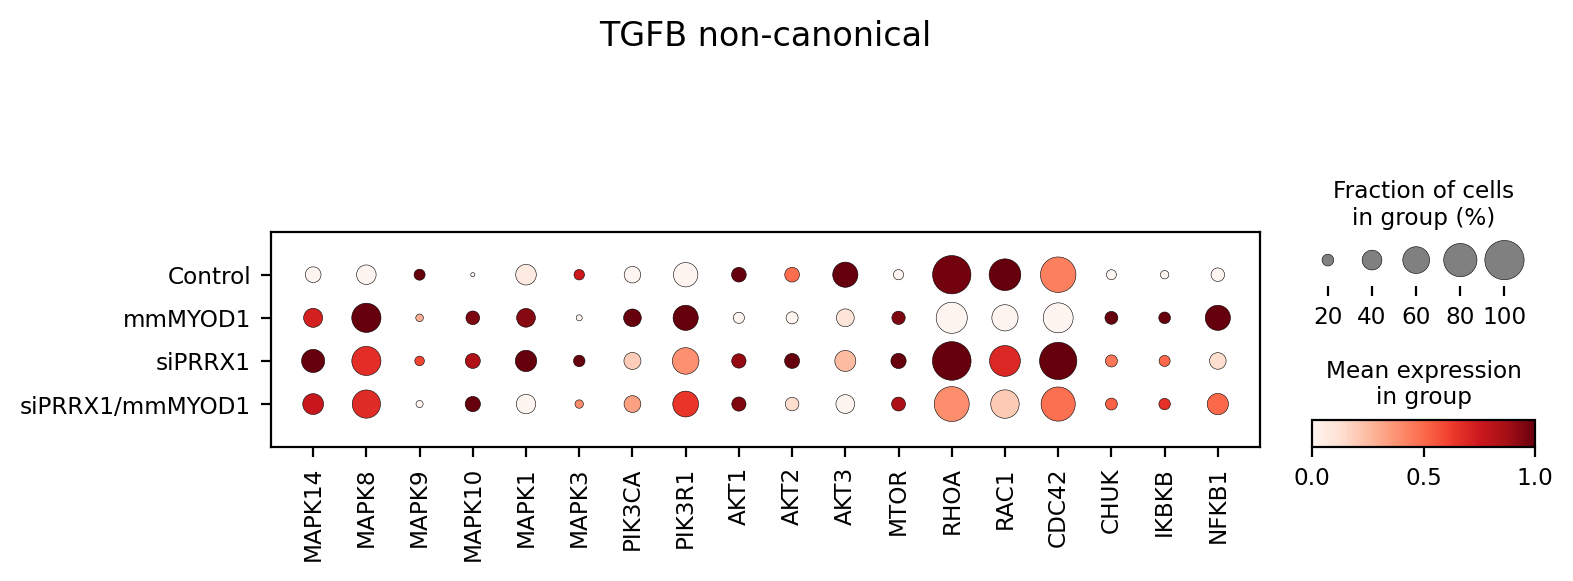

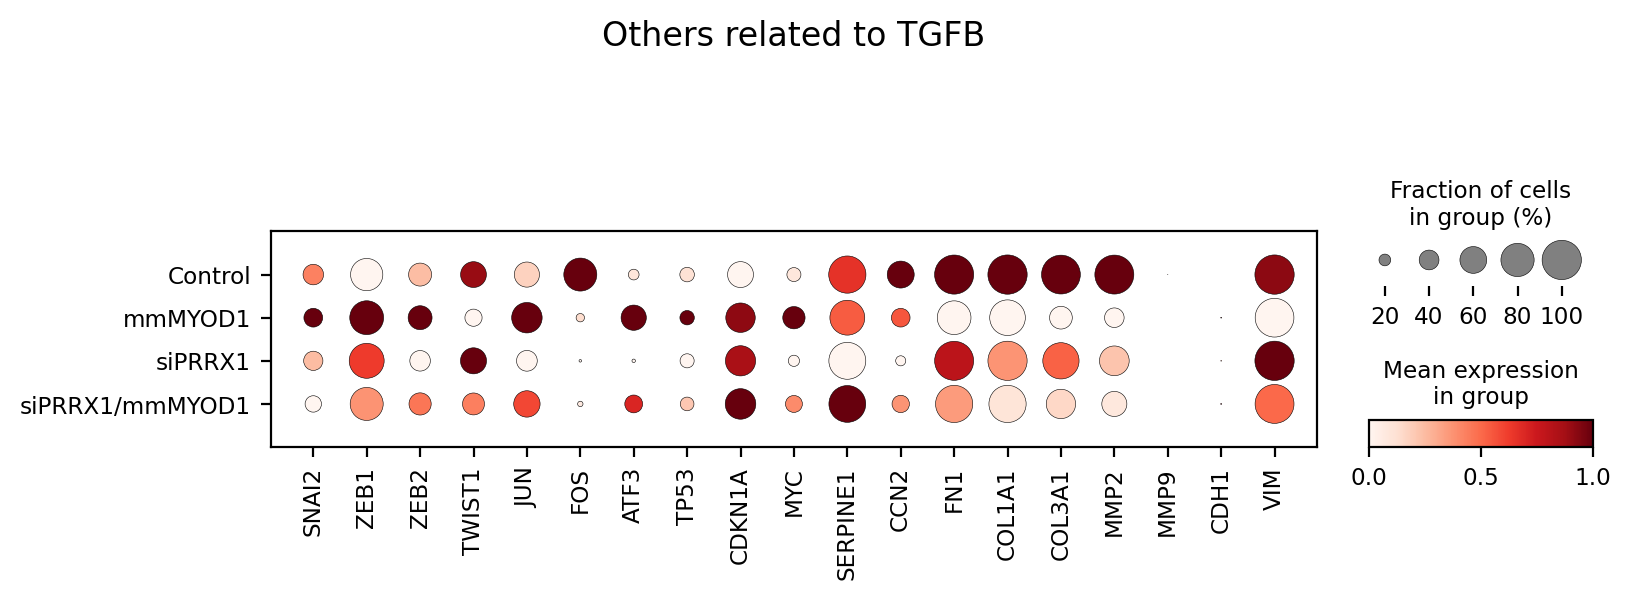

In [128]:
genes_of_interest = {
    "TGFB/SMAD signaling": ['TGFB1', 'TGFB2', 'TGFB3', 'SMAD2', 'SMAD3', 'SMAD4', 'TGFBR2', 'TGFBR1', 'ALK5', 'TGFBR3', 'ENG', 'SMAD7', 'SMURF1', 'SMURF2', 'PPM1A'],
    "SMAD co-factors": ['EP300', 'CREBBP', 'FOXH1', 'RUNX1', 'RUNX2', 'YAP1', 'WWTR1', 'SP1'],
    "TGFB non-canonical": ['TAK1', 'MAPK14', 'MAPK8', 'MAPK9', 'MAPK10', 'MAPK1', 'MAPK3', 'PIK3CA', 'PIK3R1', 'AKT1', 'AKT2', 'AKT3', 'MTOR',
                           'RHOA', 'RAC1', 'CDC42', 'CHUK', 'IKBKB', 'NFKB1',],
    "Others related to TGFB": ['SNAI2', 'ZEB1', 'ZEB2', 'TWIST1', 'JUN', 'FOS', 'ATF3', 'TP53', 'CDKN1A', 'MYC', 'SERPINE1', 'CTGF', 'CCN2', 'FN1', 
                               'COL1A1', 'COL3A1', 'MMP2', 'MMP9', 'CDH1', 'VIM'],
}


for pathway, genes in genes_of_interest.items():
    
    genes_to_plot = [gene for gene in genes if gene in adata.var_names]
    
    sc.pl.dotplot(
        adata,
        groupby='pooled_condition',
        var_names=genes_to_plot,
        layer='log_norm',
        title=pathway,
        standard_scale='var',
    )

# Quiescence genes

In [51]:
fpath = "../../resources/genes_for_scoring.csv"

df = pd.read_csv(fpath)
print(df.shape)
print(df.columns.tolist())
df.head()

(512, 18)
['G1/S_transition', 'G2/M_transition', 'CC_checkpoints', 'Cell_cycle_reg', 'Pos_proliferation', 'Neg_proliferation', 'quiescence', 'AS', 'Chromatin', 'Circadian', 'Core_repro', 'NOTCH_signaling', 'Asymm_PCP', 'FOXO', 'p53_acyivity', 'DREAM/negE2F', 'senes_stress', 'sasp']


,G1/S_transition,G2/M_transition,CC_checkpoints,Cell_cycle_reg,Pos_proliferation,Neg_proliferation,quiescence,AS,Chromatin,Circadian,Core_repro,NOTCH_signaling,Asymm_PCP,FOXO,p53_acyivity,DREAM/negE2F,senes_stress,sasp
0,FBXW7,CDC25A,CHFR,YTHDF2,EMP2,IGFBP5,ATF3,CWC27,H2AJ,TEF,HDAC9,FBXW7,SMURF2,TXN,MAPK11,CDC25A,H2AZ2,H2AZ2
1,CCNP,CDK6,CDK1,PRKCA,TNXB,ZBTB7C,ATF4,DDX20,HCFC1,SFPQ,POLR2C,ST3GAL4,SMURF1,PLXNA4,TPX2,CDK1,ACD,H2BC9
2,EZH2,NES,MRNIP,OBSL1,CX3CL1,NTRK1,CTNNB1,RBM3,INO80E,THRAP3,PTN,FCER2,WNT5A,SOD2,TAF9B,E2F1,H2BC9,JUN
3,APBB1,CDK1,DGKZ,LOC102724428,CCND2,KDF1,BACH2,RBM5,HDAC8,NKX2-1,JUN,PSMA7,SCRIB,KAT2B,DYRK2,LIN52,H2BC4,UBE2C
4,DDX3X,FBXL15,BARD1,MAGEA4,LIG4,BTG3,JUN,RBM23,BAZ2A,LOC102724428,MED31,TBL1X,PSMC6,IGFBP1,MDM4,RBL1,H2BC5,H2BC4


59
computing score 'quiescence_score'
    finished (0:00:01)


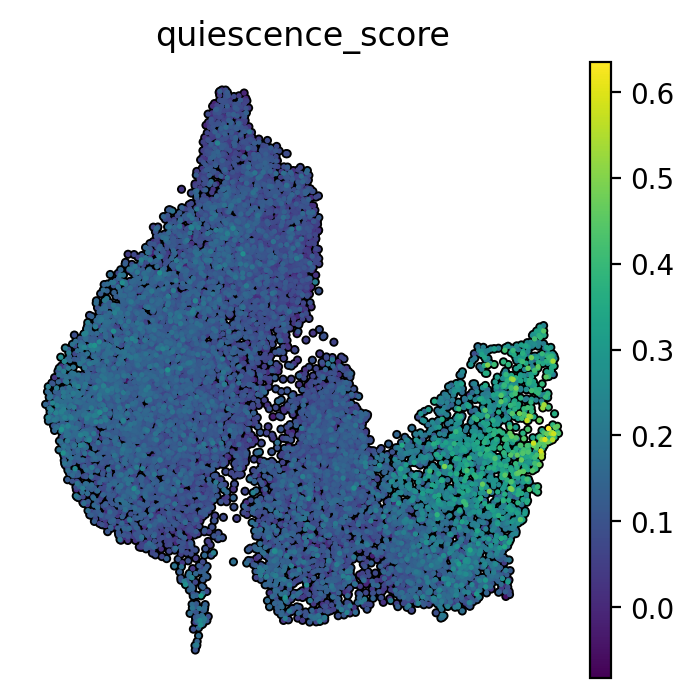

In [53]:
qui_genes = [gene for gene in df['quiescence'].unique() if gene in adata.var_names]
print(len(qui_genes))

sc.tl.score_genes(
    adata,
    gene_list=qui_genes,
    score_name='quiescence_score',
    ctrl_size=500,
    use_raw=False,
    layer='log_norm',
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['quiescence_score'],
    size=15,
    ncols=1,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

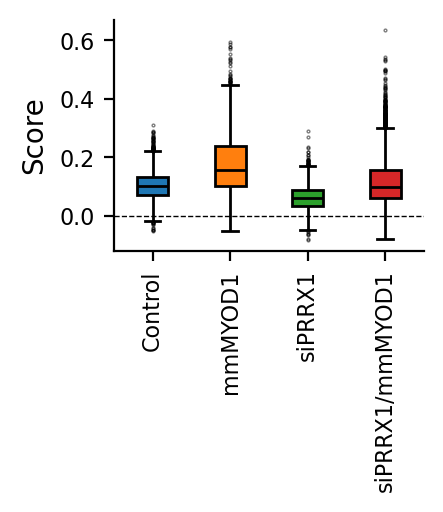

In [57]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 2, 1.5

sns.boxplot(
    data=adata.obs,
    x='pooled_condition',
    hue='pooled_condition',
    y='quiescence_score',
    width=0.4,
    linecolor='k',
    linewidth=1,
    # palette=colors,
    legend=False,
    saturation=1,
    flierprops={'markersize': 0.5, 'alpha': 0.5},
    zorder=1,
)

plt.axhline(0, linestyle='--', linewidth=0.5, color='k', zorder=0)

plt.ylabel('Score')
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8)
plt.xlabel("")
sns.despine()

plt.tight_layout()
plt.show() 

In [90]:
qdf = get_significant_DEGs(deg)

qdf = qdf[qdf['names'].isin(qui_genes)]
print(qdf['names'].nunique())

de_qui = qdf['names'].unique()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
N unique significant DEGs: 9473

40


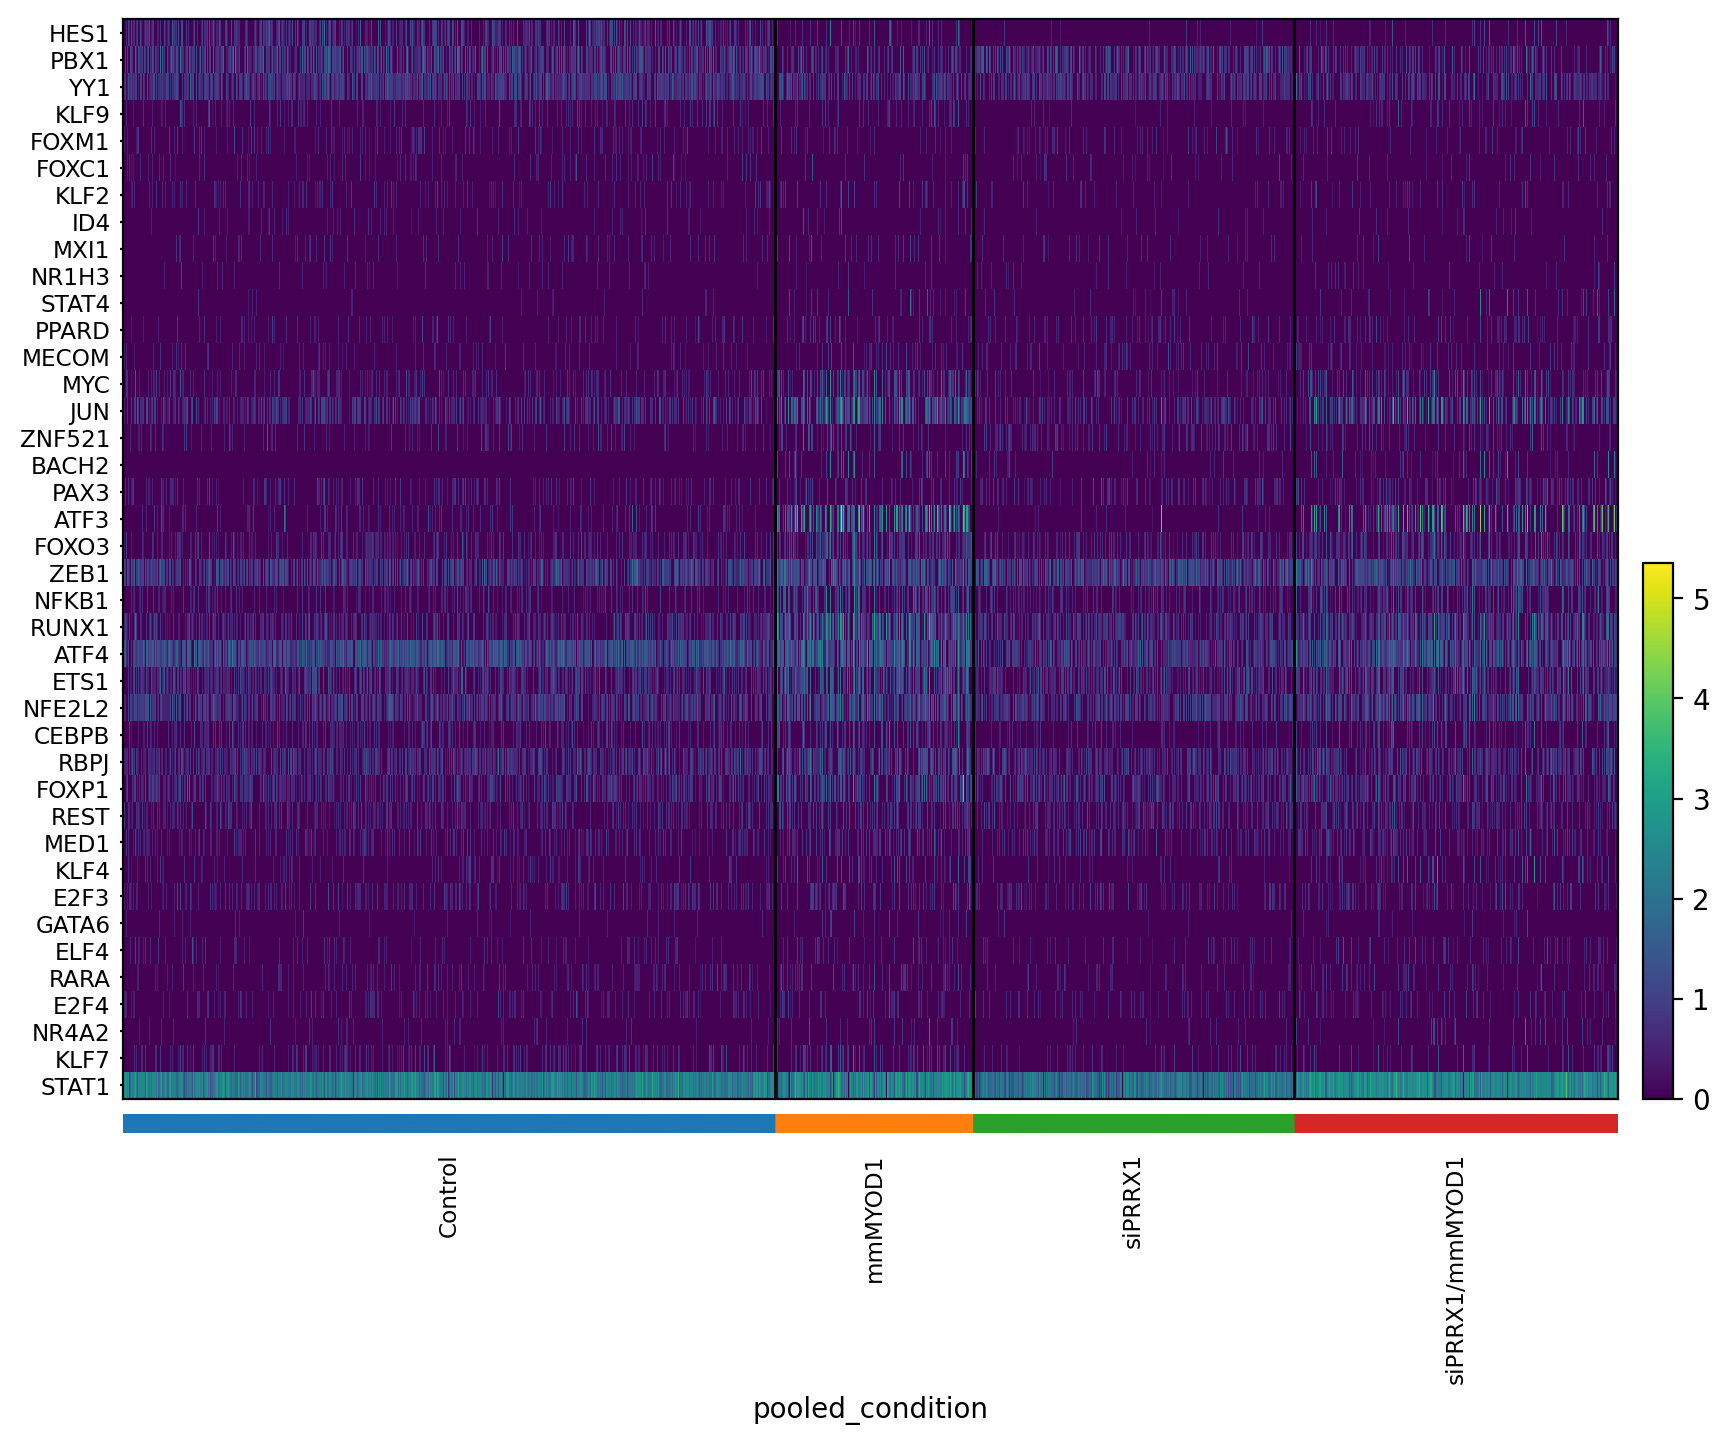

In [93]:
sc.pl.heatmap(
    adata,
    var_names=de_qui,
    groupby='pooled_condition',
    use_raw=False,
    layer='log_norm',
    swap_axes=True,
    # cmap='viridis',
    # standard_scale='var',
)

In [94]:
qdf.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,abs_lfc
134,Control,HES1,52.216782,3.096613,0.000000e+00,0.000000e+00,0.559195,0.077197,3.096613
288,Control,PBX1,32.373154,0.963578,6.553043e-230,3.090420e-228,0.746408,0.498220,0.963578
421,Control,YY1,25.539436,0.622381,7.194421e-144,1.975468e-142,0.800144,0.619689,0.622381
1070,Control,KLF9,10.876796,0.950238,1.486987e-27,1.059077e-26,0.202874,0.101335,0.950238
1446,Control,FOXM1,7.768362,0.597243,7.950786e-15,3.966997e-14,0.202874,0.126029,0.597243


In [25]:
adata.obs.head()

,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,...,log1p_total_counts_ribo,pct_counts_ribo,outlier,mt_outlier,S_score,G2M_score,phase,leiden,cluster_str,de_groups
AAACCAAAGCAACTGC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.000000,NaN,NaN,NaN,Hybrid,...,7.992269,15.716183,False,False,-0.635702,4.894103,G2M,0,C1,siPRRX1/mmMYOD1
AAACCAAAGTAGGGCA_hybrid,14.0,1.0,1.0,MYOD,16.0,0.875000,NaN,NaN,NaN,Hybrid,...,7.290293,15.135860,False,False,0.306563,-0.046410,S,1,C2,mmMYOD1
AAACCAAAGTCTAGGC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.000000,NaN,NaN,NaN,Hybrid,...,8.283494,13.937025,False,False,-1.015544,-1.571282,G1,0,C1,siPRRX1/mmMYOD1
AAACCATTCACGTAAT_hybrid,2.0,19.0,2.0,PRRX1,23.0,0.826087,NaN,NaN,NaN,Hybrid,...,7.260523,14.684015,False,False,0.139403,3.017692,G2M,2,C3,siPRRX1
AAACCATTCAGGCAGA_hybrid,0.0,22.0,0.0,PRRX1,22.0,1.000000,NaN,NaN,NaN,Hybrid,...,8.080856,17.547386,False,False,-0.391932,4.534103,G2M,2,C3,siPRRX1


# Pseudobulk by condition + phase

In [5]:
adata.obs["condition_by_phase"] = (
    adata.obs["pooled_condition"].astype(str) + "_" + adata.obs["phase"].astype(str)
)

conditions = ["Control", "mmMYOD1", "siPRRX1", "siPRRX1/mmMYOD1"]
phases = ["G1", "S", "G2M"]

ordered_categories = [f"{cond}_{ph}" for ph in phases for cond in conditions]

# Apply categorical with ordering
adata.obs["condition_by_phase"] = pd.Categorical(
    adata.obs["condition_by_phase"],
    categories=ordered_categories,
    ordered=True
)

# Now value_counts will respect this order if you use sort=False
adata.obs["condition_by_phase"].value_counts(sort=False)

condition_by_phase
Control_G1             3551
mmMYOD1_G1             1422
siPRRX1_G1             1409
siPRRX1/mmMYOD1_G1     1803
Control_S               219
mmMYOD1_S               311
siPRRX1_S               527
siPRRX1/mmMYOD1_S       612
Control_G2M            3190
mmMYOD1_G2M             376
siPRRX1_G2M            1494
siPRRX1/mmMYOD1_G2M    1036
Name: count, dtype: int64

In [6]:
# adata.obs["condition_by_phase_group"] = adata.obs["condition_by_phase"].astype(str)


phase_group_map = {
    "G1": "G1/S",
    "S": "G1/S",
    "G2M": "G2/M"
}

adata.obs["condition_by_phase_group"] = (
    adata.obs["pooled_condition"].astype(str) + "_" +
    adata.obs["phase"].map(phase_group_map)
)

# Make categorical and optionally order
conditions = ["Control", "mmMYOD1", "siPRRX1", "siPRRX1/mmMYOD1"]
phase_groups = ["G1/S", "G2/M"]
ordered_categories = [f"{cond}_{ph}" for ph in phase_groups for cond in conditions]

adata.obs["condition_by_phase_group"] = pd.Categorical(
    adata.obs["condition_by_phase_group"],
    categories=ordered_categories,
    ordered=True
)

adata.obs["condition_by_phase_group"].value_counts(sort=False)

condition_by_phase_group
Control_G1/S            3770
mmMYOD1_G1/S            1733
siPRRX1_G1/S            1936
siPRRX1/mmMYOD1_G1/S    2415
Control_G2/M            3190
mmMYOD1_G2/M             376
siPRRX1_G2/M            1494
siPRRX1/mmMYOD1_G2/M    1036
Name: count, dtype: int64

In [7]:
adata.X = adata.layers['raw_counts'].copy()

gdata = sc.get.aggregate(
    adata, 
    by='condition_by_phase_group',
    func='sum',
    axis=0,
)

gdata.X = gdata.layers['sum'].copy()

sc.pp.normalize_total(gdata, target_sum=1e4)
sc.pp.log1p(gdata)

gdata.layers['log_norm'] = gdata.X.copy()

gdata

normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 8 × 25042
    obs: 'condition_by_phase_group'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p'
    layers: 'sum', 'log_norm'

In [52]:
gdata.obs.head()

,condition_by_phase_group
Control_G1/S,Control_G1/S
mmMYOD1_G1/S,mmMYOD1_G1/S
siPRRX1_G1/S,siPRRX1_G1/S
siPRRX1/mmMYOD1_G1/S,siPRRX1/mmMYOD1_G1/S
Control_G2/M,Control_G2/M


In [47]:
cdata = gdata[:, gdata.var_names.isin(cc_genes)].copy()
cdata

AnnData object with n_obs × n_vars = 8 × 210
    obs: 'condition_by_phase_group'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p'
    layers: 'sum', 'log_norm'

In [41]:
cdata.var.head()

,gene_id,gene_type,Chromosome,Start,End,mt,ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,...,total_counts,log1p_total_counts,n_counts,filter_pass,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches
gene_name,,,,,,,,,,,,,,,,,,,,,
ABCB1,ENSG00000085563,protein_coding,chr7,87503016,87713323,False,False,191,0.012013,0.011942,...,232.0,5.451038,216.0,False,False,NaN,0.007611,0.006228,1.132972,0
ACVR1B,ENSG00000135503,protein_coding,chr12,51951698,51997078,False,False,1128,0.062034,0.060186,...,1198.0,7.089243,1118.0,False,False,NaN,0.038690,0.023565,0.972536,0
AMBRA1,ENSG00000110497,protein_coding,chr11,46396413,46594125,False,False,8145,0.599731,0.469835,...,11582.0,9.357294,11115.0,False,False,NaN,0.336097,0.148999,0.898875,0
ANLN,ENSG00000011426,protein_coding,chr7,36389820,36453791,False,False,8596,1.570371,0.944050,...,30327.0,10.319827,29705.0,False,True,540.0,0.572099,0.402881,1.755597,2
ANP32E,ENSG00000143401,protein_coding,chr1,150218416,150236156,False,False,12269,2.348022,1.208370,...,45345.0,10.722077,44339.0,False,True,1014.5,0.851747,0.419508,1.566665,2


In [42]:
cc_dict.keys()

dict_keys(['G1', 'G1/S_transition', 'S', 'G2/M_transition', 'G2M'])

In [8]:
G1S_cells = gdata.obs.query("condition_by_phase_group.str.contains('G1/S')").index
G2M_cells = gdata.obs.query("condition_by_phase_group.str.contains('G2/M')").index

In [9]:
G1S_genes = []
for phase in ["G1", "G1/S_transition", "S"]:
    G1S_genes.extend(cc_dict[phase])

G1S_genes = [str(g) for g in G1S_genes]
G1S_genes_filtered = [g for g in G1S_genes if g in gdata.var_names]
    
    
G2M_genes = []
for phase in ["G2/M_transition", "G2M"]:
    G2M_genes.extend(cc_dict[phase])
    
G2M_genes = [str(g) for g in G2M_genes]
G2M_genes_filtered = [g for g in G2M_genes if g in gdata.var_names]
    
# extract pseudobulk expression matrix
X_G1S = gdata[G1S_cells, G1S_genes_filtered].X.toarray()
X_G2M = gdata[G2M_cells, G2M_genes_filtered].X.toarray()

X__G1S_z = (X_G1S - X_G1S.mean(axis=0)) / X_G1S.std(axis=0, ddof=0)
X_G2M_z = (X_G2M - X_G2M.mean(axis=0)) / X_G2M.std(axis=0, ddof=0)

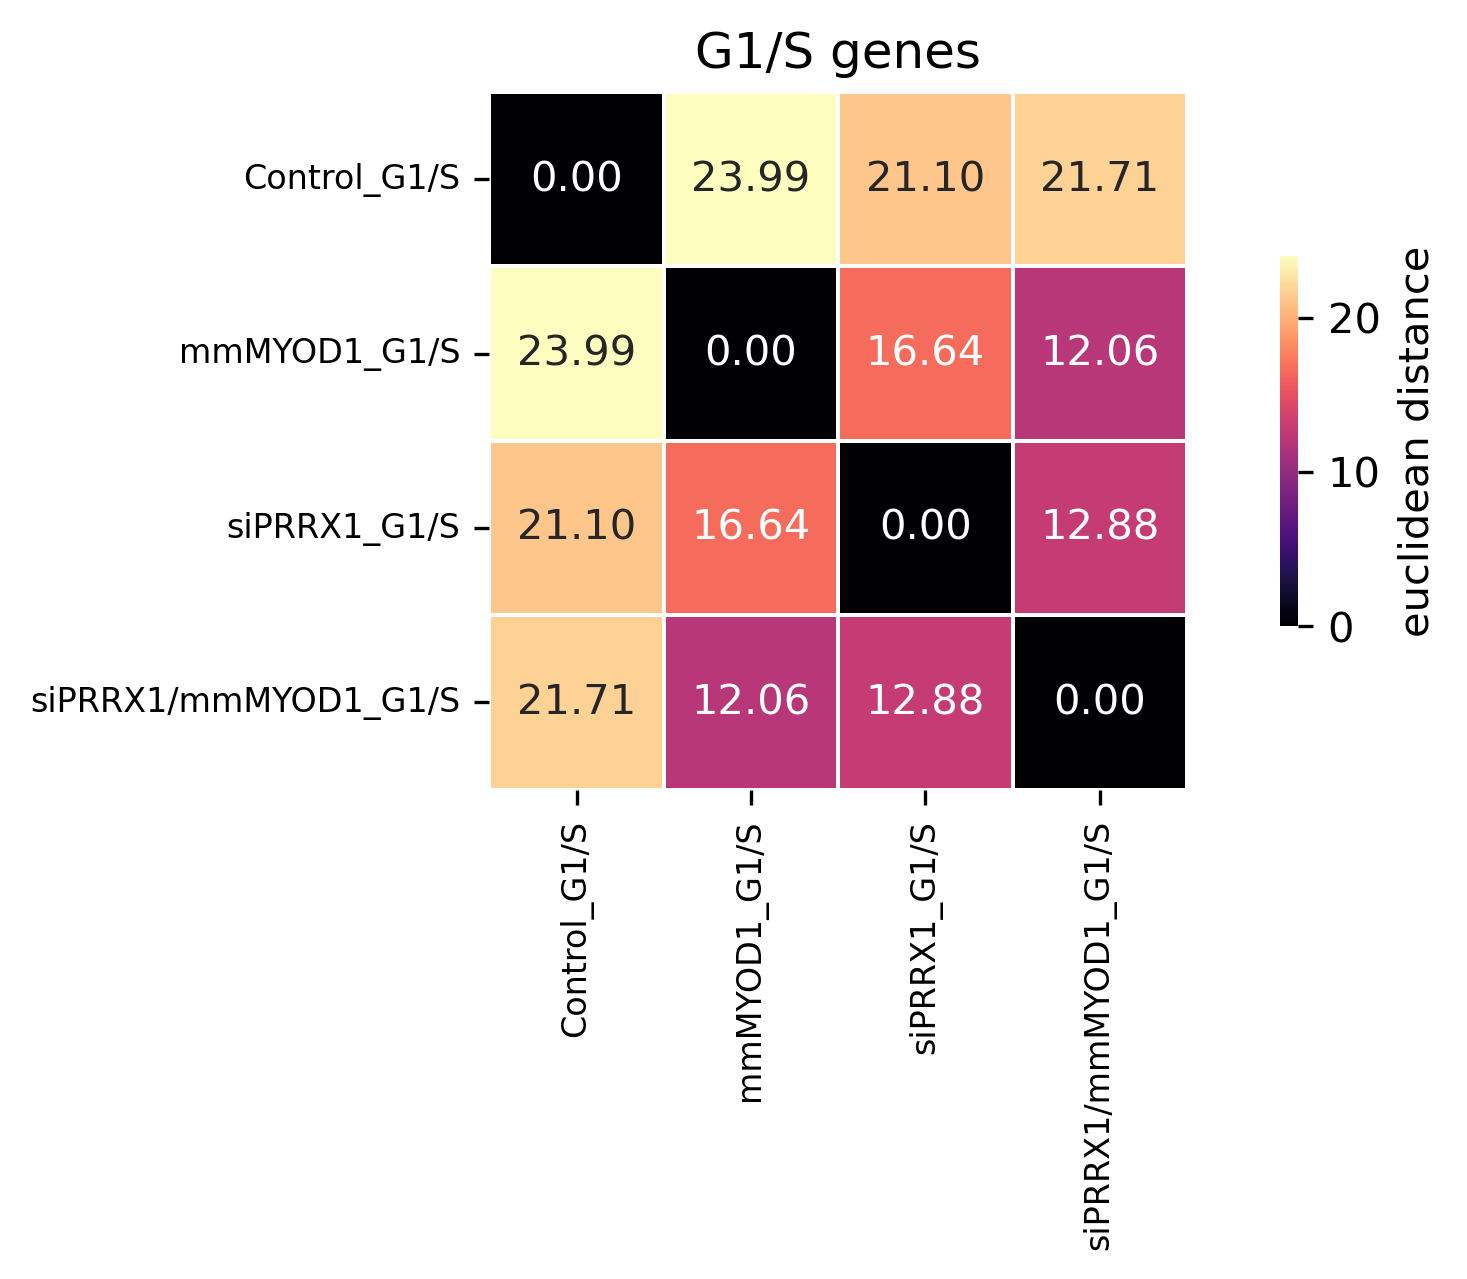

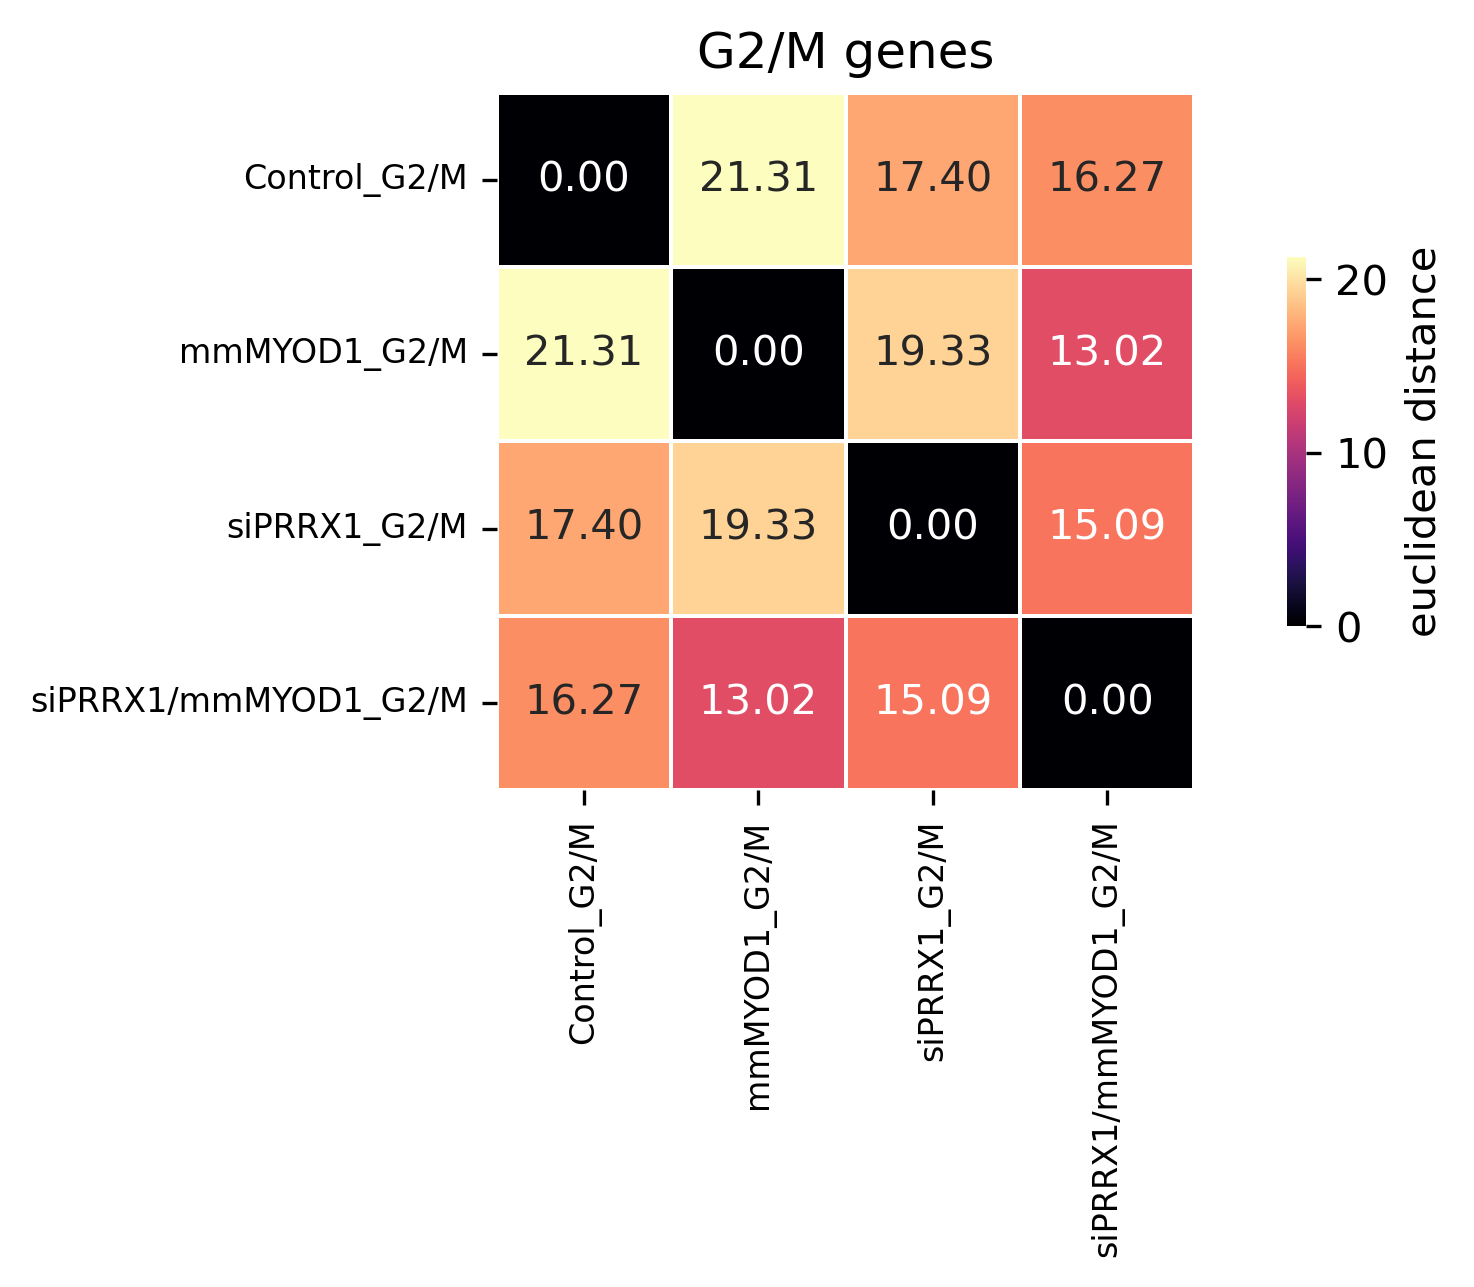

In [19]:
def corr_distance_heatmap(X, labels, metric, title=""):
    dist = squareform(pdist(X, metric=metric))
    dist_df = pd.DataFrame(dist, index=labels, columns=labels)

    plt.figure(figsize=(4,4))
    sns.heatmap(
        dist_df,
        cmap="magma",
        square=True,
        annot=True,
        fmt=".2f",
        lw=0.5,
        cbar_kws={'label':f'{metric} distance', 'shrink': 0.4, 'pad': 0.1},
    )
    
    plt.xlabel("")
    plt.ylabel("")
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    
    plt.title(title)
    plt.show()


plt.rcParams['figure.dpi'] = 300

metric = 'euclidean'

# G1/S
labels_G1S = gdata.obs.loc[G1S_cells, "condition_by_phase_group"]
corr_distance_heatmap(
    X__G1S_z,
    # X_G1S,
    labels_G1S,
    metric=metric,
    title="G1/S genes",
)

# G2/M
labels_G2M = gdata.obs.loc[G2M_cells, "condition_by_phase_group"]
corr_distance_heatmap(
    X_G2M_z,
    # X_G2M,
    labels_G2M,
    metric=metric,
    title="G2/M genes",
)

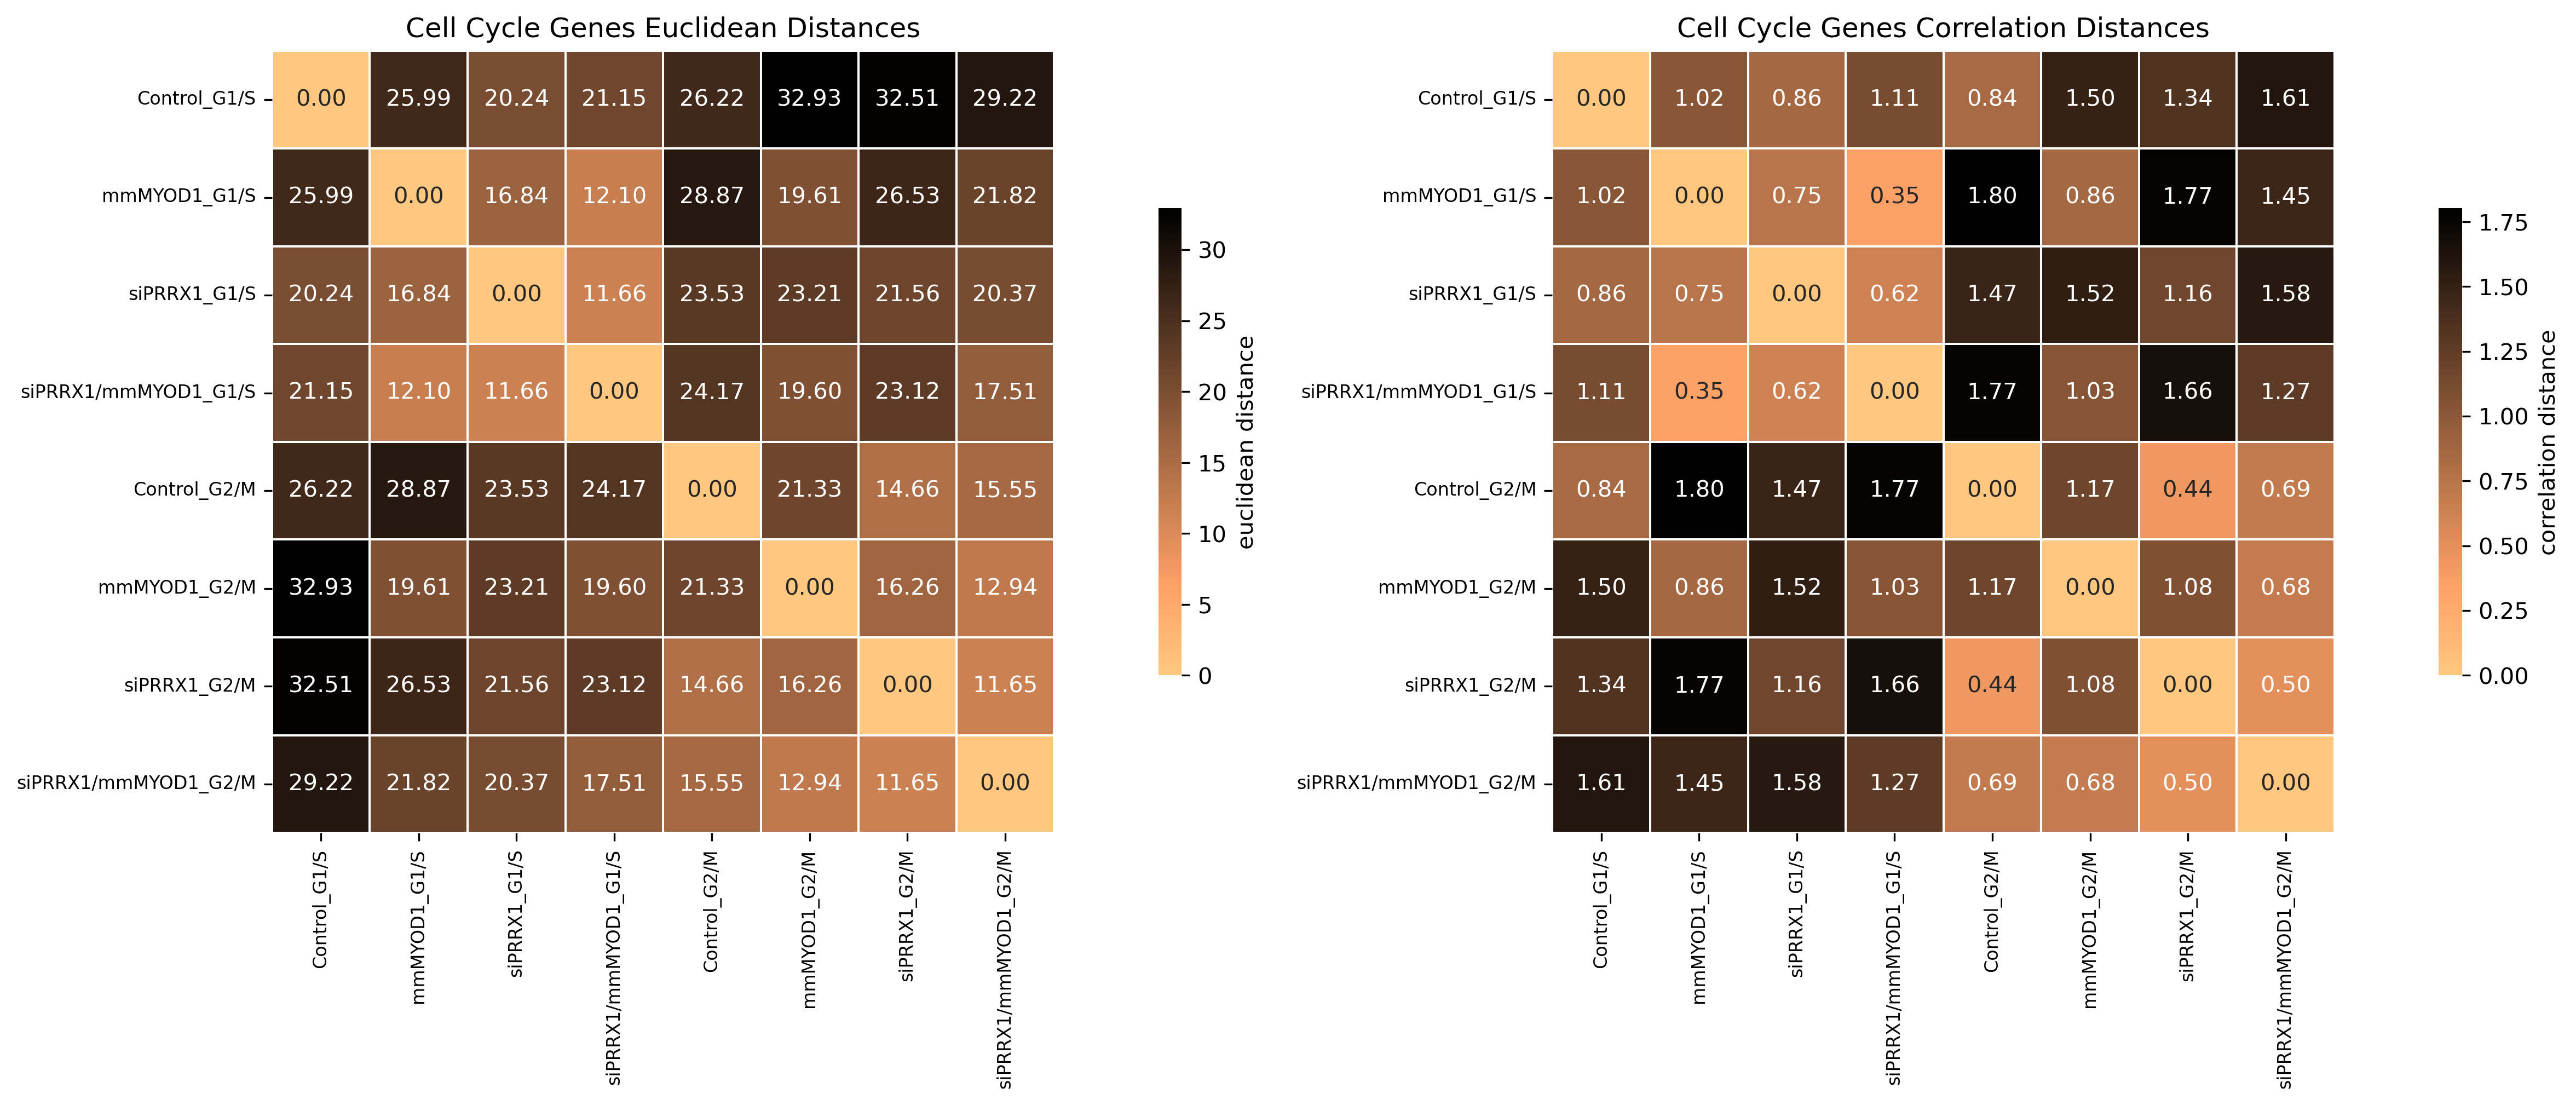

In [50]:
def plot_distance_heatmap(
    X,
    labels,
    metric="euclidean",
    title="change me",
    ax=None,
    figsize=(7.5, 7.5),
    cmap='bwr',
    column_filter=None,
    row_filter=None,
    norm=None,
    column_rank=False,
    row_rank=False,
):
    """
    Compute and plot a heatmap of pairwise distances.

    Parameters:
    - X: dense or sparse expression matrix (cells x genes)
    - labels: list of labels for each cell
    - metric: distance metric for pdist (default: "euclidean")
    - title: heatmap title
    - ax: optional matplotlib axis object
    - figsize: tuple (width, height) in inches
    - cmap: colormap for heatmap
    - column_filter: list of label values to include in the columns of distance matrix
    - row_filter: list of label values to include in the rows of distance matrix
    - norm: can be (1 for rows, 0 for columns, or None)
    - column_rank: if true, return values as column ranks
    - row_rank: if true, return values as row ranks
    """
    X_dense = X.toarray() if not isinstance(X, np.ndarray) else X
    distance_matrix = squareform(pdist(X_dense, metric=metric))
    distance_df = pd.DataFrame(distance_matrix, index=labels, columns=labels)

    if ax is None:
        plt.rcParams['figure.dpi'] = 300
        fig, ax = plt.subplots(figsize=figsize)

    if not column_filter is None:
        distance_df = distance_df[column_filter]

    if not row_filter is None:
        distance_df = distance_df.loc[row_filter]

    if norm == 1:
        # Z-score normalization across rows
        distance_df = distance_df.sub(distance_df.mean(axis=1), axis=0)
        distance_df = distance_df.div(distance_df.std(axis=1), axis=0)
    elif norm == 0:
        # Z-score normalization across columns
        distance_df = distance_df.sub(distance_df.mean(axis=0), axis=1)
        distance_df = distance_df.div(distance_df.std(axis=0), axis=1)
    elif norm is None:
        # No normalization
        distance_df = distance_df.copy()
    else:
        raise ValueError("norm must be 1 (rows), 0 (columns), or None")

    if column_rank:
        distance_df = distance_df.rank(axis=1)
    if row_rank:
        distance_df = distance_df.rank(axis=0)

    sns.heatmap(
        distance_df,
        cmap=cmap,
        square=True,
        annot=True,
        fmt=".2f",
        lw=0.5,
        cbar_kws={'label': f'{metric} distance', 'shrink': 0.4, 'pad': 0.1},
        ax=ax,
    )

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

    if ax is None:
        plt.tight_layout()
        plt.show()
        
        
        
X = cdata.X.copy()

# Compute Z score for genes
X_z = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0)

labels = cdata.obs['condition_by_phase_group'].tolist()

metrics = [
    "euclidean",
    # "cosine",
    "correlation",
]

n = len(metrics)
plot_height = 8

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (plot_height * n), plot_height
fig, axes = plt.subplots(1, n)

for i, metric in enumerate(metrics):
    plot_distance_heatmap(
        X_z, 
        # X,
        labels, 
        metric=metric, 
        title=f'Cell Cycle Genes {metric.title()} Distances', 
        ax=axes[i],
        # cmap='bwr',
        cmap='copper_r',
        # norm=0,
    )

plt.tight_layout()

In [ ]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (5, 5)
fig, axes = plt.subplots()

plot_distance_heatmap(
    X, 
    labels, 
    metric='correlation', 
    title=f'Cell Cycle Genes', 
    ax=axes[i],
    norm=0,
)

plt.tight_layout()